In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
df = pd.read_csv('all_my_music_cleaned.csv')

In [ ]:
df.head()

## Data Overview

In [ ]:
df.shape
df.dtypes
df.describe()

## Top Artists

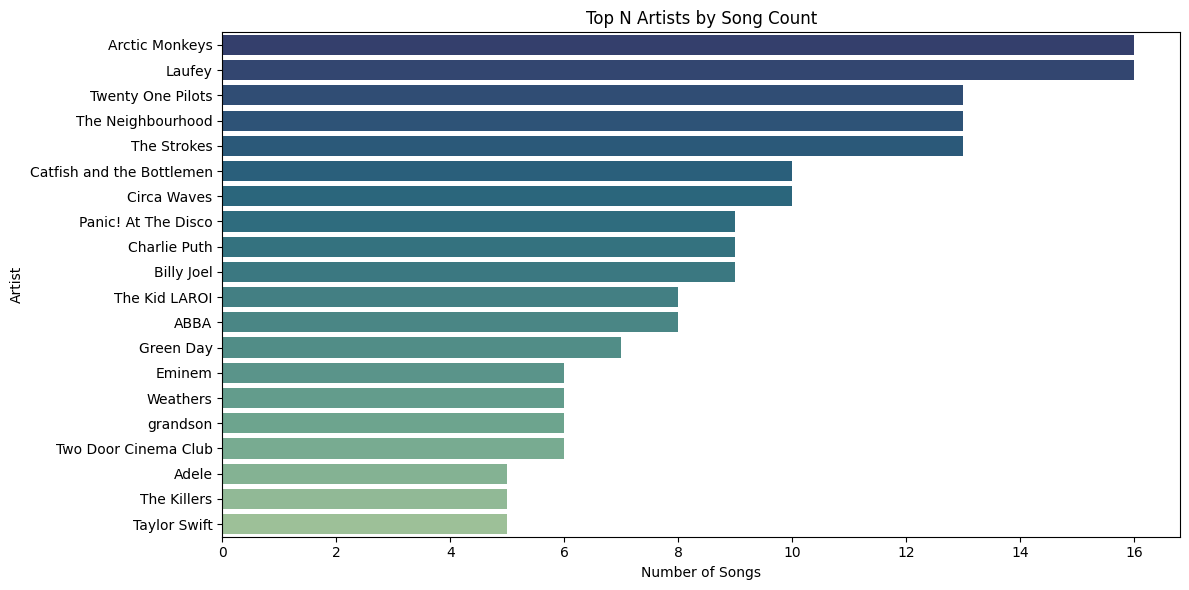

In [44]:
top_number = 20
top_artists_all = df['Artist Name(s)'].value_counts()
top_artists = top_artists_all.head(top_number)

plt.figure(figsize=(12,6))
sns.barplot(x = top_artists.values, y = top_artists.index, hue=top_artists.index, palette='crest_r', legend = False)
plt.title('Top N Artists by Song Count')
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

## Eclecticness (how many times does an artist appear once, twice, and so on)

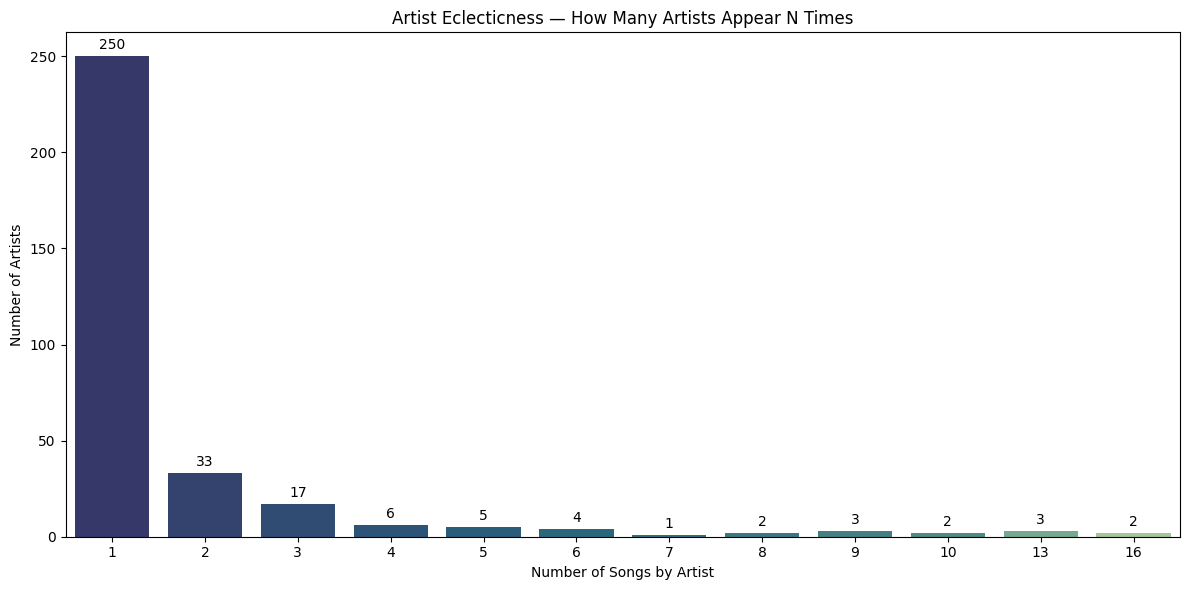

In [14]:
freq_artists = top_artists_all.value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=freq_artists.index, y=freq_artists.values, hue = freq_artists.index, palette='crest_r', legend = False)
plt.title('Artist Eclecticness — How Many Artists Appear N Times')
plt.xlabel('Number of Songs by Artist')
plt.ylabel('Number of Artists')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Release Year Frequency

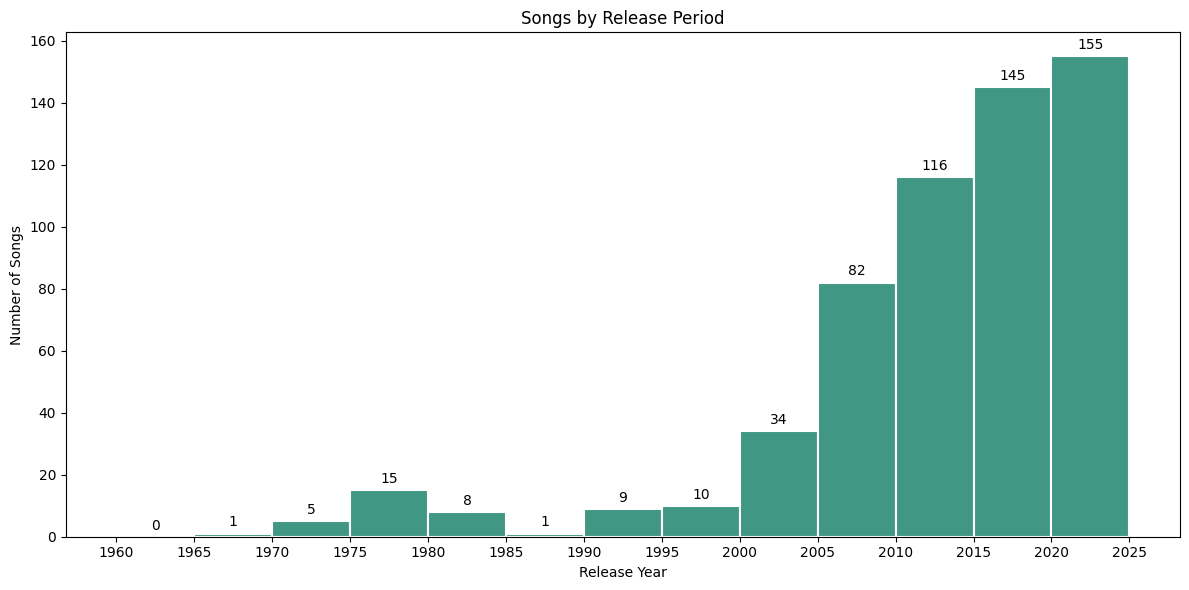

In [33]:
df['Release Date'] = pd.to_datetime(df['Release Date'], format='mixed')
release_year = df['Release Date'].dt.year

decade_bins = range(1960, 2030, 5)

plt.figure(figsize=(12, 6))
sns.histplot(x=release_year, bins=decade_bins, color="#00765B", edgecolor='white', linewidth=1.5)
plt.title('Songs by Release Period')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.xticks(range(1960, 2030, 5))
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Genres

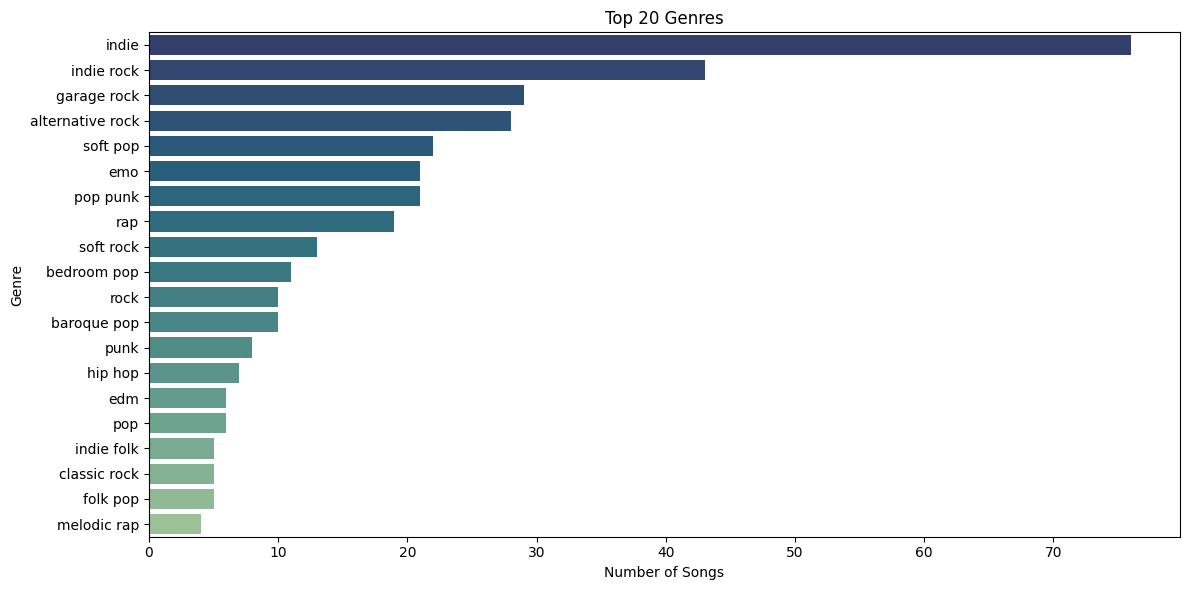

In [45]:
all_genres = df['Genres'].dropna().str.split(',').explode().str.strip()
all_genres.value_counts().head(20)

top_genres = all_genres.value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest_r', hue = top_genres.index, legend = False)
plt.title('Top 20 Genres')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()